In [9]:
import sys
sys.path.insert(0, '/home/bnc2119/MEDAL')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from src.medal.eval_utils import load_and_split, get_teacher_embeddings
from src.medal.core import AutoEncoder
import torch
from pathlib import Path
from sklearn.model_selection import train_test_split
PATH_PREFIX = '/share/ctn/users/bnc2119/drd_data' 
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
X, X_test, y, y_test = load_and_split("mnist", test_size=0.2, seed=0, labels=True)
attr_mnist_tsne_793 = np.load('attr_mnist_tsne_793.npy')
global_imp_mnist_tsne_793 = np.load('global_imp_mnist_tsne_793.npy')

attr_mnist_umap_18 = np.load('attr_mnist_umap_18.npy')
global_imp_mnist_umap_18 = np.load('global_imp_mnist_umap_18.npy')

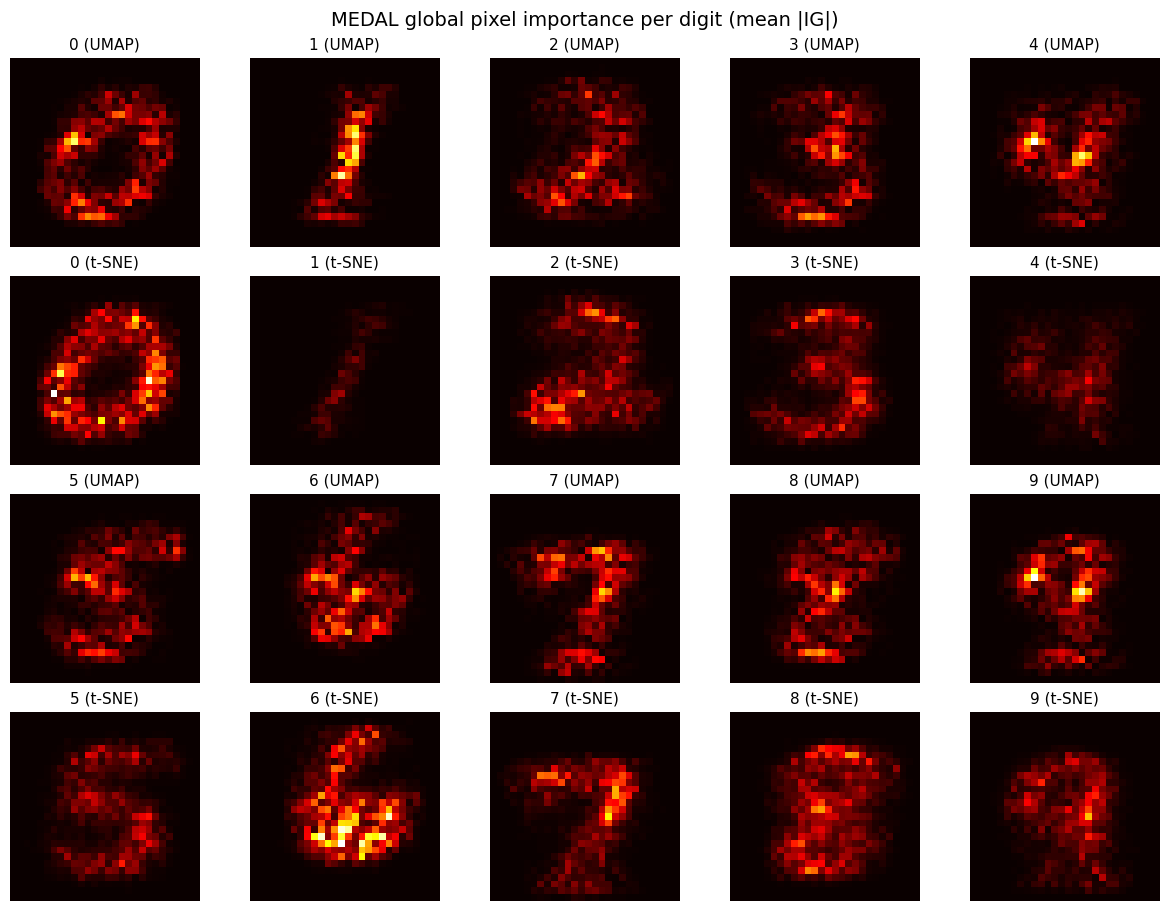

In [8]:
def digit_global_imp_img(attr_arr, y_int, d):
    idx = np.where(y_int == d)[0]
    if idx.size == 0:
        return np.full((28, 28), np.nan)  # should never happen, but safe
    return np.abs(attr_arr[idx]).mean(axis=0).reshape(28, 28)

fig, axes = plt.subplots(
    nrows=4, ncols=5, figsize=(12, 9),
    constrained_layout=True
)

# Helper to draw a row of 5 digits
def plot_row(row_axes, digit_list, attr_arr, title_prefix=None, show_cbar=False):

    imgs = [digit_global_imp_img(attr_arr, y, d) for d in digit_list]
    vmax = np.nanmax([im.max() for im in imgs])

    last_im = None
    for ax, d, im in zip(row_axes, digit_list, imgs):
        last_im = ax.imshow(im, cmap="hot", vmin=0, vmax=vmax)
        ax.set_title(f"{d}" if title_prefix is None else f"{d} ({title_prefix})", fontsize=11)
        ax.axis("off")

    if show_cbar and last_im is not None:
        # Put one colorbar for the entire row (attached to the row axes)
        fig.colorbar(last_im, ax=row_axes, fraction=0.02, pad=0.02)

# Digits split
top = ['0', '1', '2', '3', '4']
bot = ['5', '6', '7', '8', '9']

# Row 0: 0-4 UMAP
plot_row(axes[0], top, attr_mnist_umap_18, title_prefix="UMAP", show_cbar=False)
axes[0, 0].set_ylabel("UMAP", fontsize=12)

# Row 1: 0-4 t-SNE
plot_row(axes[1], top, attr_mnist_tsne_793, title_prefix="t-SNE", show_cbar=False)
axes[1, 0].set_ylabel("t-SNE", fontsize=12)

# Row 2: 5-9 UMAP
plot_row(axes[2], bot, attr_mnist_umap_18, title_prefix="UMAP", show_cbar=False)
axes[2, 0].set_ylabel("UMAP", fontsize=12)

# Row 3: 5-9 t-SNE
plot_row(axes[3], bot, attr_mnist_tsne_793, title_prefix="t-SNE", show_cbar=False)
axes[3, 0].set_ylabel("t-SNE", fontsize=12)

fig.suptitle("MEDAL global pixel importance per digit (mean |IG|)", fontsize=14)
plt.show()


In [12]:
X, X_test, y, y_test = load_and_split("hydra", test_size=0.2, seed=0, labels=True)
attr_hydra_tsne_2320 = np.load('attr_hydra_tsne_2320.npy')
global_imp_hydra_tsne_2320 = np.load('global_imp_hydra_tsne_2320.npy')

W_gene_by_pc = np.load(Path(PATH_PREFIX) / "hydra_pca_loadings.npy")

# 2) map PC -> gene
gene_imp = np.abs(attr_hydra_tsne_2320) @ np.abs(W_gene_by_pc.T)

In [15]:
out = {}
for g in np.unique(y):
    idx = np.where(y == g)[0]
    out[g] = gene_imp[idx].mean(axis=0)

In [26]:
gene_names = pd.read_csv(Path(PATH_PREFIX) / 'genes.tsv',sep='\t', header=None)[0].values
def top_genes_from_vector_np(vec, gene_names, topk=30):
    """
    Get top-k genes from a 1D importance vector, using NumPy only.

    Parameters
    ----------
    vec : array-like, shape (G,)
    gene_names : list[str], length G
    topk : int

    Returns
    -------
    list of (gene, score) sorted by descending score
    """
    vec = np.asarray(vec)
    top_idx = np.argpartition(vec, -topk)[-topk:]
    top_idx = top_idx[np.argsort(vec[top_idx])[::-1]]
    return [(gene_names[i], float(vec[i])) for i in top_idx]

# 4) Print global top genes
# print("\n=== Global top genes ===")
# print(top_genes_from_vector_np(gene_imp_global, gene_names, topk=20))

# 5) Print top genes per cell type
print("\n=== Top genes per cell type ===")
for ct, vec in out.items():
    print(f"\n[{ct}]")
    print(top_genes_from_vector_np(vec, gene_names, topk=15))



=== Top genes per cell type ===

[db]
[('t19917aep', 21.178488225520606), ('t10266aep', 21.094243337208464), ('t22774aep', 21.08462319053603), ('t8644aep', 21.074829667042057), ('t10459aep', 21.052747139562534), ('t18682aep-CSL3-ONCKE', 21.021235445225237), ('t22763aep-CATL-SARPE', 20.991904277912745), ('t18683aep-LPHN-DROMO', 20.913704421498913), ('t22780aep-BHMT1-XENLA', 20.901916202149913), ('t34741aep', 20.885456165844747), ('t26674aep', 20.832389485756067), ('t578aep', 20.809861704230407), ('t12931aep', 20.80608073320949), ('t22805aep', 20.77355554882033), ('t35773aep-FRIS-LYMST', 20.76094941800545)]

[ecEp-nb(pd)]
[('t15258aep', 2.8429835484312833), ('t753aep', 2.7899020451575027), ('t25351aep', 2.7597305138263937), ('t9945aep', 2.7314372237171134), ('t5467aep', 2.708186593498377), ('t25276aep', 2.707075441039047), ('t28720aep-RS4-XENTR', 2.6783845511596307), ('t24481aep', 2.673049285989165), ('t16925aep-COMI-DICDI', 2.651313107327892), ('t14440aep-TBA1C-HUMAN', 2.64328219903960

In [24]:
pd.read_csv(Path(PATH_PREFIX) / 'genes.tsv',sep='\t', header=None)[0].values

array(['t33417aep-AAPT1-ARATH', 't33418aep-ZBED8-BOVIN',
       't37645aep-CP4V2-MOUSE', ..., 'MT-ND6', 'MT-trna0', 'MT-trna2'],
      shape=(33391,), dtype=object)

[('t12881aep-FCA1-TRYRA', 5.788178461261838), ('t23176aep-LAMC-DROME', 5.747490342775651), ('t36310aep-CPI1-PIG', 5.634303030027113), ('t23177aep-LAMC-DROME', 5.600042675655557), ('t25825aep', 5.522783630421222), ('t33064aep', 5.517444870920709), ('t6769aep', 5.512840283661209), ('t19198aep-PCR5-ARATH', 5.506147450462262), ('t18616aep-PRY1-YEAST', 5.489021268831159), ('t6390aep-TXNIP-PONAB', 5.4041905239695724), ('t19413aep', 5.384383113962907), ('t8295aep-SAXO1-MACFA', 5.384322905230682), ('t10351aep', 5.382217725880032), ('t8473aep-NECX-APLCA', 5.378811785461797), ('t28520aep', 5.37101933200996)]

[i_male_germline]
[('t11585aep-H2BL1-PSAMI', 5.89336338651392), ('t19014aep', 5.781188601078086), ('t38683aep-H10A-XENLA', 5.772360214455377), ('t7000aep', 5.731560454715077), ('t9510aep', 5.645070895514835), ('t22193aep-H10-HUMAN', 5.6170687086677376), ('t2754aep-SYCE2-MOUSE', 5.582466816469208), ('t2965aep-SYCP1-MOUSE', 5.550534216386337), ('t21631aep-RSPH1-MOUSE', 5.5129173284301825), ('t848aep', 5.506759922753941), ('t6307aep', 5.463563143475885), ('t33373aep', 5.4524890504382375), ('t2390aep-SYCP3-BOVIN', 5.414169095786341), ('t21135aep-ZGLP1-MOUSE', 5.20348684309691), ('t7432aep-BOULE-DROME', 5.177536047427689)]